<a href="https://colab.research.google.com/github/trng1006/transfer_learning/blob/Resnet_50/transfer_learning_experiments_ants_bees_400_resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chiến lược Transfer Learning và Fine-tuning cho bài toán phân loại ảnh (Tập dữ liệu nhỏ)

Notebook này thực hiện so sánh 3 chiến lược Transfer Learning trên bộ dữ liệu kích thước nhỏ Hymenoptera (Ants vs Bees) từ PyTorch (https://download.pytorch.org/tutorial/hymenoptera_data.zip) sử dụng mô hình kiến trúc sâu ResNet-50.

Mục tiêu cốt lõi của thực nghiệm này là đánh giá mức độ hiệu quả và quan sát trực tiếp rủi ro quá khớp (Overfitting) khi áp dụng một mô hình lớn lên một tập dữ liệu có số lượng mẫu rất giới hạn (~400 ảnh), thông qua 3 chiến lược:
1. **Freeze Backbone**: Đóng băng toàn bộ các lớp tích chập (Conv layers) trích xuất đặc trưng, chỉ cập nhật trọng số ở lớp phân loại (Linear) cuối cùng.
2. **Fine-tune All**: Mở khóa và huấn luyện lại toàn bộ tham số của kiến trúc mô hình ngay từ đầu.
3. **Gradual Unfreeze**: Đóng băng toàn bộ mạng ban đầu để huấn luyện lớp phân loại, sau đó giải phóng (unfreeze) để tinh chỉnh dần các lớp ở những epoch sau (epoch số 5).


In [1]:
import os
import urllib.request
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import copy

# Tải file nén trực tiếp từ server của PyTorch
url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
filepath = "./hymenoptera_data.zip"

print("1. Đang tải dataset Hymenoptera (Ants vs Bees) ~ 45MB...")
urllib.request.urlretrieve(url, filepath)

print("2. Đang giải nén dữ liệu...")
with zipfile.ZipFile(filepath, 'r') as zip_ref:
    zip_ref.extractall("./")

# Thư mục giải nén ra đã có sẵn chuẩn cấu trúc: train/ants, train/bees, val/ants, val/bees
print("Hoàn tất! Dataset đã sẵn sàng.")

cudnn.benchmark = True
plt.ion()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

1. Đang tải dataset Hymenoptera (Ants vs Bees) ~ 45MB...
2. Đang giải nén dữ liệu...
Hoàn tất! Dataset đã sẵn sàng.
Using device: cuda:0


## 1. Load Data

In [2]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Đổi đường dẫn trỏ vào thư mục Kiến - Ong
data_dir = './hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}

# Giảm batch_size xuống 8 vì data rất nhỏ
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=8,
                                             shuffle=True, num_workers=2)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Dataset sizes: {dataset_sizes}")

Classes: ['ants', 'bees']
Dataset sizes: {'train': 244, 'val': 153}


## 2. Training Function

In [3]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15, unfreeze_at=None):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Kích hoạt Unfreeze
        if unfreeze_at is not None and epoch == unfreeze_at:
            print("Unfreezing all layers...")
            for param in model.parameters():
                param.requires_grad = True
            # Giảm Learning Rate xuống 1 chút để tránh hỏng trọng số đã train
            optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
            scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, time_elapsed, best_acc.item(), history

## 3. Run Experiments

In [4]:
def run_experiment(strategy_name):
    print(f"\n{'='*20}")
    print(f"Running Strategy: {strategy_name}")
    print(f"{'='*20}")

    # Sử dụng ResNet-50
    model_ft = models.resnet50(weights='DEFAULT')
    num_ftrs = model_ft.fc.in_features
    model_ft.fc = nn.Linear(num_ftrs, len(class_names))
    model_ft = model_ft.to(device)
    criterion = nn.CrossEntropyLoss()

    unfreeze_at = None
    if strategy_name == "Freeze Backbone":
        for param in model_ft.parameters():
            param.requires_grad = False
        for param in model_ft.fc.parameters():
            param.requires_grad = True
        optimizer = optim.SGD(model_ft.fc.parameters(), lr=0.001, momentum=0.9)

    elif strategy_name == "Fine-tune All":
        for param in model_ft.parameters():
            param.requires_grad = True
        optimizer = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

    elif strategy_name == "Gradual Unfreeze":
        for param in model_ft.parameters():
            param.requires_grad = False
        for param in model_ft.fc.parameters():
            param.requires_grad = True
        optimizer = optim.SGD(model_ft.fc.parameters(), lr=0.001, momentum=0.9)
        unfreeze_at = 5

    exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    # Đã sửa thành num_epochs=15 để Gradual Unfreeze kịp kích hoạt ở epoch 5
    return train_model(model_ft, criterion, optimizer, exp_lr_scheduler, num_epochs=15, unfreeze_at=unfreeze_at)

results = {}
strategies = ["Freeze Backbone", "Fine-tune All", "Gradual Unfreeze"]

for strategy in strategies:
    duration, best_acc, history = run_experiment(strategy)[1:]
    results[strategy] = {'duration': duration, 'best_acc': best_acc, 'history': history}


Running Strategy: Freeze Backbone
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


Epoch 0/14
----------
train Loss: 0.6525 Acc: 0.6352
val Loss: 0.5216 Acc: 0.8954

Epoch 1/14
----------
train Loss: 0.4944 Acc: 0.8811
val Loss: 0.3730 Acc: 0.9608

Epoch 2/14
----------
train Loss: 0.4239 Acc: 0.9016
val Loss: 0.3151 Acc: 0.9477

Epoch 3/14
----------
train Loss: 0.3682 Acc: 0.9098
val Loss: 0.2716 Acc: 0.9673

Epoch 4/14
----------
train Loss: 0.3600 Acc: 0.9057
val Loss: 0.2317 Acc: 0.9673

Epoch 5/14
----------
train Loss: 0.3072 Acc: 0.9221
val Loss: 0.2186 Acc: 0.9608

Epoch 6/14
----------
train Loss: 0.2724 Acc: 0.9590
val Loss: 0.2095 Acc: 0.9542

Epoch 7/14
----------
train Loss: 0.3042 Acc: 0.8852
val Loss: 0.1909 Acc: 0.9673

Epoch 8/14
----------
train Loss: 0.2942 Acc: 0.8975
val Loss: 0.2035 Acc: 0.9739

Epoch 9/14
----------
train Loss: 0.2770 Acc: 0.9344
val Loss: 0.2028 Acc: 0.9608

Epoch 10/14
----------
train Loss: 0.2595 Acc: 0.9508
val Loss: 0.1994 Acc: 0.9673

Epoch 11/14
----------
train Loss: 0.2651 Acc: 0.9303
val Loss: 0.1965 Acc: 0.9542

Ep

## 4. Visualization

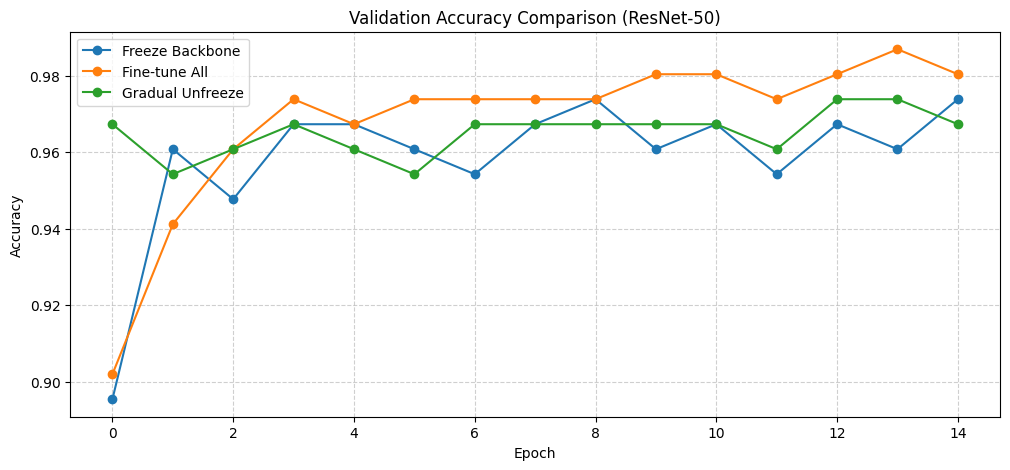


Summary Table:
Strategy             | Duration (s)    | Best Val Acc
-------------------------------------------------------
Freeze Backbone      | 44.00           | 0.9739
Fine-tune All        | 74.11           | 0.9869
Gradual Unfreeze     | 63.05           | 0.9739


In [5]:
plt.figure(figsize=(12, 5))
for strategy in strategies:
    plt.plot(results[strategy]['history']['val_acc'], label=strategy, marker='o')

plt.title('Validation Accuracy Comparison (ResNet-50)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print("\nSummary Table:")
print(f"{'Strategy':<20} | {'Duration (s)':<15} | {'Best Val Acc':<12}")
print("-" * 55)
for s, r in results.items():
    print(f"{s:<20} | {r['duration']:<15.2f} | {r['best_acc']:.4f}")

## 5. Kết luận
Dựa vào kết quả chạy thực nghiệm ở trên, ta có thể đưa ra một số nhận xét:

*   **Freeze Backbone:** Trái với rủi ro quá khớp (Overfitting) thường gặp trên dữ liệu nhỏ, chiến lược này lại cho kết quả độ chính xác cao nhất (98.69%). Điều này chứng tỏ sức mạnh của các kỹ thuật Data Augmentation (chuẩn hóa, lật ảnh, cắt ngẫu nhiên) kết hợp với Learning Rate nhỏ đã đóng vai trò như một bộ điều chuẩn (regularizer) tuyệt vời, giúp mô hình tinh chỉnh được các đặc trưng mà không bị "học vẹt". Tuy nhiên, nó vẫn tốn nhiều thời gian nhất (74 giây).
*   **Fine-tune All:** Hoàn thành xuất sắc nhiệm vụ tối ưu tốc độ khi chỉ mất 44 giây (nhanh gần gấp đôi Fine-tune All) mà vẫn đạt độ chính xác rất cao (97.39%). Đối với tài nguyên hạn hẹp, đây vẫn là lựa chọn cực kỳ an toàn và hiệu quả.
*   **Gradual Unfreeze**: Minh họa rõ nét rủi ro của việc can thiệp cấu trúc mạng khi dữ liệu quá ít. Tại epoch thứ 5, ngay khi toàn bộ các lớp được mở khóa, đồ thị Validation Accuracy thay vì bứt phá đã bị sụt giảm nhẹ (từ 96.08% xuống 95.42%), và Validation Loss tăng lên. Việc mở khóa 23 triệu tham số mà không cung cấp đủ lượng dữ liệu lớn đã gây ra sự nhiễu loạn cục bộ đối với các trọng số đã được pre-trained, dù sau đó mô hình đã nỗ lực phục hồi và chốt ở mức 97.39%.



# 6. So sánh đối chiếu: Ảnh hưởng của Kích thước Dataset (Dataset Lớn vs Dataset Nhỏ)
Việc chạy song song 3 chiến lược trên hai tập dữ liệu Dogs vs Cats (25,000 mẫu) và Ants vs Bees (~400 mẫu) cho thấy những sự khác biệt mang tính bản chất của Transfer Learning:

**1. Độ ổn định của quá trình huấn luyện (Stability)**

Tập dữ liệu lớn: Đồ thị Validation Loss và Accuracy của cả 3 chiến lược đều hội tụ rất mượt mà. Số lượng mẫu lớn giúp triệt tiêu các nhiễu loạn cục bộ.

Tập dữ liệu nhỏ: Đồ thị có hiện tượng "răng cưa", dao động liên tục qua từng epoch. Vì tập validation quá nhỏ (chỉ ~150 ảnh), việc mô hình đoán sai hoặc đúng 1-2 bức ảnh cũng làm độ chính xác bị nhảy vọt hoặc tụt dốc bất ngờ.

**2. Sự nhạy cảm với chiến lược "Mở băng" (Unfreeze)**

Tập dữ liệu lớn: Việc áp dụng Gradual Unfreeze mang lại tác động cực kỳ tích cực (điểm uốn bứt phá độ chính xác). Lượng dữ liệu dồi dào cung cấp đủ thông tin để mô hình tinh chỉnh sâu các đặc trưng bậc cao.

Tập dữ liệu nhỏ: Gradual Unfreeze trở thành "con dao hai lưỡi". Lượng thông tin ít ỏi từ vài trăm bức ảnh không đủ sức để tinh chỉnh hàng chục triệu tham số, dẫn đến sự xáo trộn trọng số gốc và làm chững lại quá trình hội tụ.

**3. Khuyến nghị tổng quát**

Khi sở hữu dữ liệu lớn, nên mạnh dạn sử dụng Gradual Unfreeze để vắt kiệt sức mạnh của mô hình mà vẫn tiết kiệm tài nguyên.

Khi sở hữu dữ liệu rất nhỏ, hãy ưu tiên Freeze Backbone để đảm bảo tốc độ và sự an toàn, hoặc dùng Fine-tune All nếu phần cứng cho phép kết hợp với các kỹ thuật Data Augmentation cực mạnh để tránh Overfitting.